<a href="https://colab.research.google.com/github/giovannadb/transfer-learning-cat-vs-dog/blob/main/cat_vs_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/giovannadb/dataset-cat-vs-dog.git
dataset_path = './dataset-cat-vs-dog/pet-Images'

fatal: destination path 'dataset-cat-vs-dog' already exists and is not an empty directory.


In [ ]:
!ls -R dataset-cat-vs-dog/

dataset-cat-vs-dog/:
cat_vs_dogs.ipynb  pet-Images  README.md

dataset-cat-vs-dog/pet-Images:
Cat  Dog

dataset-cat-vs-dog/pet-Images/Cat:
0.jpg	 121.jpg  143.jpg  165.jpg  187.jpg  208.jpg  40.jpg  62.jpg  84.jpg
100.jpg  122.jpg  144.jpg  166.jpg  188.jpg  209.jpg  41.jpg  63.jpg  85.jpg
101.jpg  123.jpg  145.jpg  167.jpg  189.jpg  20.jpg   42.jpg  64.jpg  86.jpg
102.jpg  124.jpg  146.jpg  168.jpg  18.jpg   21.jpg   43.jpg  65.jpg  87.jpg
103.jpg  125.jpg  147.jpg  169.jpg  190.jpg  22.jpg   44.jpg  66.jpg  88.jpg
104.jpg  126.jpg  148.jpg  16.jpg   191.jpg  23.jpg   45.jpg  67.jpg  89.jpg
105.jpg  127.jpg  149.jpg  170.jpg  192.jpg  24.jpg   46.jpg  68.jpg  8.jpg
106.jpg  128.jpg  14.jpg   171.jpg  193.jpg  25.jpg   47.jpg  69.jpg  90.jpg
107.jpg  129.jpg  150.jpg  172.jpg  194.jpg  26.jpg   48.jpg  6.jpg   91.jpg
108.jpg  12.jpg   151.jpg  173.jpg  195.jpg  27.jpg   49.jpg  70.jpg  92.jpg
109.jpg  130.jpg  152.jpg  174.jpg  196.jpg  28.jpg   4.jpg   71.jpg  93.jpg
10.jpg	 131.jpg  

In [ ]:
import torchvision
import torch
import torchvision.transforms as transforms

In [ ]:
#as imagens precisam ser transformadas
#converter as imagens PIL (python image library) em tensores PyTorch e escalar os pixels para [0.0, 1.0]
#é necessário que todas as imagens em um batch tenham as mesmas dimensões para poder empilhar (stack) em um único tensor.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_dataset = torchvision.datasets.ImageFolder(dataset_path, transform=transform)

#define a proporção de divisão, por exemplo 80% para treinamento e 20% para validação
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

#divide o dataset entre treinamento e validação de forma aleatória
trainset, valset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

#carregamento de dados
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)

print(f"Number of training samples: {len(trainset)}")
print(f"Number of validation samples: {len(valset)}")
print(f"Classes: {full_dataset.classes}")

Number of training samples: 340
Number of validation samples: 86
Classes: ['Cat', 'Dog']


In [ ]:
#transformando a lista em um iterador
dataiter = iter(trainloader)
imagens, rotulos = next(dataiter)

image = imagens[0]
label = rotulos[0]

print({full_dataset.classes[label]})

{'Dog'}


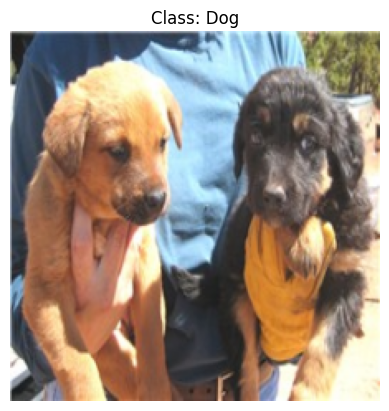

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#função para mostrar a imagem selecionada
def imshow(img, label_name):
    #converte para o matplotlib pra imagem não ficar torta
    img = img.numpy().transpose((1, 2, 0))
    plt.imshow(img)
    plt.title(f"Class: {label_name}")
    plt.axis('off')
    plt.show()

imshow(image, full_dataset.classes[label])
#toda vez que rodar o bloco anterior e esse, uma outra imagem aparecerá

In [ ]:
print(imagens[0].shape)

torch.Size([3, 224, 224])


In [ ]:
#modelo vgg16 do keras para transfer learning

In [ ]:
from torch import nn, optim
import torchvision.models as models
import torch.nn.functional as F

class Modelo(nn.Module):
  def __init__(self):
    super(Modelo, self).__init__()
    #carrega o modelo
    self.vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    for param in self.vgg.features.parameters():
      param.requires_grad = False

    self.vggclassifier = nn.Sequential(
        nn.Linear(self.vgg.classifier[0].in_features, 600),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(600, 2)
    )

  def forward(self, X):
    X = self.vgg(X)
    return F.log_softmax(X, dim=1)

In [ ]:
from time import time

def treino(modelo,trainloader, device):
  otimizador = optim.Adam(modelo.vgg.classifier.parameters(), lr=0.001)
  inicio =time()

  criterio = nn.NLLLoss()
  epochs = 4
  modelo.train()

  for epoch in range(epochs):
    perda_acumulada = 0

    for imagens, rotulos in trainloader:
      otimizador.zero_grad()

      output =modelo(imagens.to(device))
      perda_instantanea =criterio(output, rotulos.to(device))

      perda_instantanea.backward()
      otimizador.step()
      perda_acumulada += perda_instantanea.item()

  else:
    print("epochs {} - perda resultante: {}".format(epoch+1, perda_acumulada/len(trainloader)))
  print("\ntempo de treino em minutos =", (time() - inicio)/60)

In [ ]:
def validacao(modelo, valloader, device):
  modelo.eval()
  total_images_analisadas, total_acertos =0, 0
  with torch.no_grad():
    for imagens, rotulos in valloader:

      logps = modelo(imagens.to(device))
      ps = torch.exp(logps)

      _, rotulo_pred = torch.max(ps, 1)

      total_images_analisadas += rotulos.size(0)
      total_acertos += (rotulo_pred == rotulos.to(device)).sum().item()
  print("Total de imagens testadas =", total_images_analisadas)
  print("\nPrecisão do modelo = {} %".format(total_acertos*100/total_images_analisadas))

In [ ]:
modelo = Modelo()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo.to(device)

Modelo(
  (vgg): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16): Max

In [ ]:
treino(modelo, trainloader, device)

epochs 4 - perda resultante: 0.09384178884405021

tempo de treino em minutos = 16.911806766192118


In [ ]:
validacao(modelo, valloader, device)

Total de imagens testadas = 86

Precisão do modelo = 89.53488372093024 %


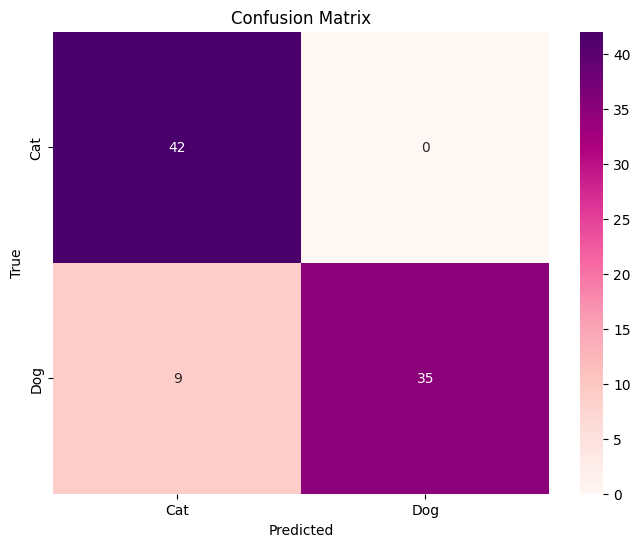

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

modelo.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
  for image, rotulos in valloader:
    logps = modelo(image.to(device))
    ps = torch.exp(logps)
    _, pred = torch.max(ps, 1)

    all_labels.extend(rotulos.cpu().numpy())
    all_predictions.extend(pred.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

class_names = full_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()